# DATA ANALYSIS

In [1]:
# import add-ons
import pandas as pd
import re
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Dense, Dropout, Concatenate
)
from tensorflow.keras.utils import plot_model
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.losses import BinaryCrossentropy

In [2]:
# clean data to remove uppercase characters, non-word characters, and extra whitespace
def clean_text(text):
    text = str(text).lower()  # remove uppercase       
    text = re.sub(r"\W", " ", text) # remove non-word characters
    text = re.sub(r"\s+", " ", text) # remove whitespace 
    return text.strip()

df = pd.read_csv("../data/firestick_reviews_cleaned.csv")

# apply clean_text to necessary columns 
df["title"] = df["title"].apply(clean_text) 
df["text"] = df["text"].apply(clean_text)


# remove reviews with 3-star ratings
df_edited = df[df['rating'] != 3]
df.to_csv("../data/filtered_firestick_reviews.csv", index=False)

In [3]:
# create a label for the star-ratings: 1 for 4-5 stars, 0 for 1-2 stars 
df_edited = df_edited.copy()
df_edited["label"] = df_edited["rating"].apply(lambda x: 1 if x >= 4 else 0)


# save to filtered csv 
df_edited.to_csv("../data/filtered_firestick_reviews.csv", index=False)

In [4]:
# create a df combining the text for the title and text columns 
df_edited["combined_text"] = (df_edited["title"].astype(str) + df_edited["text"].astype(str))


# check the average length of the combined text
df_edited['review_len'] = df_edited['combined_text'].apply(lambda x: len(str(x).split()))
print(df_edited['review_len'].describe())

count    166149.000000
mean         24.403939
std          36.863365
min           0.000000
25%           5.000000
50%          13.000000
75%          30.000000
max        1195.000000
Name: review_len, dtype: float64


In [5]:
MAX_WORDS = 60000    # based on number of rows 
MAX_LEN = 50    # based on average length of text       

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<UNK>") # replace words that are not in vocab 
tokenizer.fit_on_texts(df_edited["combined_text"]) # assign integers to words

X = tokenizer.texts_to_sequences(df_edited["combined_text"]) # convert sequence text into sequence of integers 
X = pad_sequences(X, maxlen=MAX_LEN) # makes all sequences = to max_len (50)

y = df_edited["label"].values

In [6]:
# create a train split
# one train split with stratification
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# one train split without stratification
X_train_nostrat, X_val_nostrat, y_train_nostrat, y_val_nostrat = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
# build the text CNN to classify the reviews 
embedding_dim = 128 # size of each word vector 

inputs = Input(shape=(MAX_LEN,)) # each input is a sequence of integers with length MAX_LEN
embedding = Embedding(MAX_WORDS, embedding_dim)(inputs) # convert words into vectors 

conv_3 = Conv1D(128, 3, activation="relu")(embedding)  # convolutions with different kernel sizes based on word-phrase size 
conv_4 = Conv1D(128, 4, activation="relu")(embedding)
conv_5 = Conv1D(128, 5, activation="relu")(embedding)

pool_3 = GlobalMaxPooling1D()(conv_3) # reduces size of each input 
pool_4 = GlobalMaxPooling1D()(conv_4)
pool_5 = GlobalMaxPooling1D()(conv_5)

concat = Concatenate()([pool_3, pool_4, pool_5]) # pooled inputs combined 
dropout = Dropout(0.5)(concat)  # to prevent overfitting 
output = Dense(1, activation="sigmoid")(dropout)  # outputs predicted class 

model = Model(inputs, output)
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

# Save a visualization
plot_model(
    model,
    to_file='../outputs/text_cnn_model.png',
    show_shapes=True,
    show_layer_names=True,
    dpi=50  
);


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 50, 128)   │  7,680,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 48, 128)   │     49,280 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 47, 128)   │     65,664 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 46, 128)   │     82,048 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_3[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_4[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_5[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 384)       │          0 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        385 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,877,377 (30.05 MB)

 Trainable params: 7,877,377 (30.05 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# train model on train split for 5 epochs 
# stratified split
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=128
)

Epoch 1/30
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 39s 37ms/step - accuracy: 0.9539 - loss: 0.1160 - val_accuracy: 0.9660 - val_loss: 0.0853
Epoch 2/30
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 43s 41ms/step - accuracy: 0.9749 - loss: 0.0665 - val_accuracy: 0.9677 - val_loss: 0.0822
Epoch 3/30
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.9848 - loss: 0.0425 - val_accuracy: 0.9662 - val_loss: 0.0927
Epoch 4/30
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - accuracy: 0.9915 - loss: 0.0249 - val_accuracy: 0.9632 - val_loss: 0.1119
Epoch 5/30
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step - accuracy: 0.9953 - loss: 0.0142 - val_accuracy: 0.9651 - val_loss: 0.1348
Epoch 6/30
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 57s 55ms/step - accuracy: 0.9974 - loss: 0.0085 - val_accuracy: 0.9632 - val_loss: 0.1535
Epoch 7/30
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 56s 53ms/step - accuracy: 0.9981 - loss: 0.0058 - val_accuracy: 0.9612 - val_loss: 0.1807
Epoch 8/30
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 53s 51ms/step - accuracy: 0.9983 -

In [9]:
# nonstratified split
model_nostrat = tf.keras.models.clone_model(model)
history_nostrat = model_nostrat.fit(
    X_train_nostrat,
    y_train_nostrat,
    validation_data=(X_val_nostrat, y_val_nostrat),
    epochs=30,
    batch_size=128
)

Epoch 1/30
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 101s 97ms/step - accuracy: 0.9523 - loss: 0.1181 - val_accuracy: 0.9671 - val_loss: 0.0847
Epoch 2/30
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 100s 97ms/step - accuracy: 0.9742 - loss: 0.0667 - val_accuracy: 0.9689 - val_loss: 0.0829
Epoch 3/30
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 102s 98ms/step - accuracy: 0.9844 - loss: 0.0422 - val_accuracy: 0.9671 - val_loss: 0.0970
Epoch 4/30
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 107s 103ms/step - accuracy: 0.9914 - loss: 0.0246 - val_accuracy: 0.9655 - val_loss: 0.1130
Epoch 5/30
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 104s 101ms/step - accuracy: 0.9957 - loss: 0.0133 - val_accuracy: 0.9634 - val_loss: 0.1400
Epoch 6/30
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 105s 101ms/step - accuracy: 0.9973 - loss: 0.0082 - val_accuracy: 0.9628 - val_loss: 0.1587
Epoch 7/30
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 111s 107ms/step - accuracy: 0.9981 - loss: 0.0062 - val_accuracy: 0.9624 - val_loss: 0.1773
Epoch 8/30
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 122s 117ms/step - accur

In [10]:
# confusion matrix for stratified split 
# predict probabilities
y_prob = model.predict(X_val, batch_size=128)

# convert probabilities to class labels (0 or 1)
y_pred = (y_prob > 0.5).astype(int).flatten()

# plot confusion matrix 
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred Negative','Pred Positive'],
            yticklabels=['Actual Negative','Actual Positive'])
plt.title("Statified Split Confusion Matrix", fontsize=16)
plt.ylabel("Actual", fontsize=14)
plt.xlabel("Predicted", fontsize=14)
plt.savefig("../outputs/confusion_matrices/stratified_confusion_matrix.png", dpi=100) 
plt.close()


# confusion matrix for nonstratified split 
# predict probabilities
y_prob_nostrat = model.predict(X_val_nostrat, batch_size=128)

# convert probabilities to class labels (0 or 1)
y_pred_nostrat = (y_prob_nostrat > 0.5).astype(int).flatten()

# plot confusion matrix 
cm_nostrat = confusion_matrix(y_val_nostrat, y_pred_nostrat)

plt.figure(figsize=(6,5))
sns.heatmap(cm_nostrat, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred Negative','Pred Positive'],
            yticklabels=['Actual Negative','Actual Positive'])
plt.title("Nonstratified Split Confusion Matrix", fontsize=16)
plt.ylabel("Actual", fontsize=14)
plt.xlabel("Predicted", fontsize=14)
plt.savefig("../outputs/confusion_matrices/nonstratified_confusion_matrix.png", dpi=100) 
plt.close()



260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [12]:
# metric table for stratified split
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
bce = BinaryCrossentropy()
cross_entropy = bce(y_val, y_prob).numpy() 

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "Cross-Entropy Loss"],
    "Value": [accuracy, precision, recall, f1, cross_entropy]
})

print(metrics_df)

# plot the DataFrame as a table
fig, ax = plt.subplots()
ax.axis('off')
ax.table(cellText=metrics_df.values, colLabels=metrics_df.columns, loc='center')

# save as image
plt.savefig("../outputs/metrics_tables/stratified_metrics_table.png", dpi=150)
plt.close()




# metric table for nonstratified split
accuracy_nostrat = accuracy_score(y_val_nostrat, y_pred_nostrat)
precision_nostrat = precision_score(y_val_nostrat, y_pred_nostrat)
recall_nostrat = recall_score(y_val_nostrat, y_pred_nostrat)
f1_nostrat = f1_score(y_val_nostrat, y_pred_nostrat)
bce_nostrat = BinaryCrossentropy()
cross_entropy_nostrat = bce(y_val_nostrat, y_prob_nostrat).numpy() 

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "Cross-Entropy Loss"],
    "Value": [accuracy_nostrat, precision_nostrat, recall_nostrat, f1_nostrat, cross_entropy_nostrat]
})

print(metrics_df)

# plot the DataFrame as a table
fig, ax = plt.subplots()
ax.axis('off')
ax.table(cellText=metrics_df.values, colLabels=metrics_df.columns, loc='center')

# save as image
plt.savefig("../outputs/metrics_tables/nonstratified_metrics_table.png", dpi=150)
plt.close()


               Metric     Value
0            Accuracy  0.960126
1           Precision  0.973164
2              Recall  0.982390
3            F1 Score  0.977755
4  Cross-Entropy Loss  0.351276
               Metric     Value
0            Accuracy  0.992687
1           Precision  0.995362
2              Recall  0.996467
3            F1 Score  0.995915
4  Cross-Entropy Loss  0.064165


In [13]:
# check class distribution
def print_distribution(name, y):
    unique, counts = np.unique(y, return_counts=True)
    print(f"{name} distribution:", dict(zip(unique, counts)))

print_distribution("Original", y)
print_distribution("Train (Stratified)", y_train)
print_distribution("Val (Stratified)", y_val)
print_distribution("Train (No Strat)", y_train_nostrat)
print_distribution("Val (No Strat)", y_val_nostrat)

Original distribution: {np.int64(0): np.int64(17938), np.int64(1): np.int64(148211)}
Train (Stratified) distribution: {np.int64(0): np.int64(14350), np.int64(1): np.int64(118569)}
Val (Stratified) distribution: {np.int64(0): np.int64(3588), np.int64(1): np.int64(29642)}
Train (No Strat) distribution: {np.int64(0): np.int64(14431), np.int64(1): np.int64(118488)}
Val (No Strat) distribution: {np.int64(0): np.int64(3507), np.int64(1): np.int64(29723)}


Data is very imbalanced because only ~10% of the data is negative (17,038 negative, 148,211 positive). Since 90% of the data is positive, if the model were to guess 1 everytime, there is automatically 90% accuracy. 

# Mitigating the Class Imbalance

In [14]:
# Get indices for each class
pos_idx = np.where(y == 1)[0]
neg_idx = np.where(y == 0)[0]

n = min(len(pos_idx), len(neg_idx)) # ensure equal size of classes 

# sample equal amount
pos_sample = np.random.choice(pos_idx, n, replace=False) # randomly sample from positive 
neg_sample = np.random.choice(neg_idx, n, replace=False) # randomly sample from negative 

balanced_idx = np.concatenate([pos_sample, neg_sample]) # combine samples 
np.random.shuffle(balanced_idx) # shuffles samples 

# new set 
X_bal = X[balanced_idx]
y_bal = y[balanced_idx]


In [15]:
# create new split with balanced data 
X_train_bal, X_val_bal, y_train_bal, y_val_bal = train_test_split(
    X_bal,
    y_bal,
    test_size=0.2,
    random_state=42,   
)

In [16]:
# apply model to balanced split  
model_bal = tf.keras.models.clone_model(model)
history_bal = model_bal.fit(
    X_train_bal,
    y_train_bal,
    validation_data=(X_val_bal, y_val_bal),
    epochs=30,
    batch_size=128
)

Epoch 1/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - accuracy: 0.8929 - loss: 0.2568 - val_accuracy: 0.9366 - val_loss: 0.1663
Epoch 2/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 27s 122ms/step - accuracy: 0.9520 - loss: 0.1279 - val_accuracy: 0.9436 - val_loss: 0.1529
Epoch 3/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 27s 120ms/step - accuracy: 0.9713 - loss: 0.0800 - val_accuracy: 0.9412 - val_loss: 0.1630
Epoch 4/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 26s 118ms/step - accuracy: 0.9857 - loss: 0.0444 - val_accuracy: 0.9374 - val_loss: 0.2040
Epoch 5/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 30s 135ms/step - accuracy: 0.9917 - loss: 0.0247 - val_accuracy: 0.9369 - val_loss: 0.2261
Epoch 6/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 25s 111ms/step - accuracy: 0.9968 - loss: 0.0124 - val_accuracy: 0.9339 - val_loss: 0.2539
Epoch 7/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 24s 107ms/step - accuracy: 0.9982 - loss: 0.0064 - val_accuracy: 0.9302 - val_loss: 0.2855
Epoch 8/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 24s 106ms/step - accuracy: 0.9988 - loss: 0

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


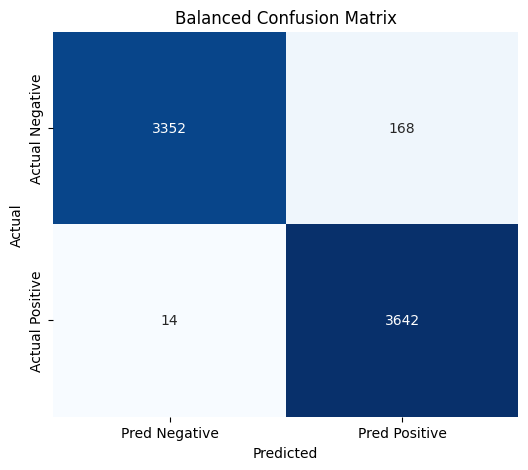

In [17]:
# predict probabilities
y_prob_bal = model.predict(X_val_bal, batch_size=128)

# convert probabilities to class labels (0 or 1)
y_pred_bal = (y_prob_bal > 0.5).astype(int).flatten()

# balanced split confusion matrix
cm_bal = confusion_matrix(y_val_bal, y_pred_bal)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_bal, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=['Pred Negative','Pred Positive'],
    yticklabels=['Actual Negative','Actual Positive']
)
plt.title("Balanced Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../outputs/confusion_matrices/balanced_confusion_matrix.png", dpi=100)

In [19]:
# metric table for balanced split
accuracy_bal = accuracy_score(y_val_bal, y_pred_bal)
precision_bal = precision_score(y_val_bal, y_pred_bal)
recall_bal = recall_score(y_val_bal, y_pred_bal)
f1_bal = f1_score(y_val_bal, y_pred_bal)
bce_bal = BinaryCrossentropy()
cross_entropy_bal = bce_bal(y_val_bal, y_prob_bal).numpy() 

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "Cross-Entropy Loss"],
    "Value": [accuracy_bal, precision_bal, recall_bal, f1_bal, cross_entropy_bal]
})

print(metrics_df)

# plot the DataFrame as a table
fig, ax = plt.subplots()
ax.axis('off')
ax.table(cellText=metrics_df.values, colLabels=metrics_df.columns, loc='center')

# save as image
plt.savefig("../outputs/metrics_tables/balanced_metrics_table.png", dpi=150)
plt.close()

               Metric     Value
0            Accuracy  0.974638
1           Precision  0.955906
2              Recall  0.996171
3            F1 Score  0.975623
4  Cross-Entropy Loss  0.221130
